In [1]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from datetime import datetime
import os

# Use the multimodal embedding function (CLIP handles images)
embedding_function = OpenCLIPEmbeddingFunction()
data_loader = ImageLoader()

client = chromadb.Client()

collection = client.get_or_create_collection(
    name="Pet_Image_Collection",
    embedding_function=embedding_function,
    data_loader=data_loader,
    metadata={
        "description": "A collection of dog and cat images",
        "created": str(datetime.now())
    }
)

# Get all image paths from image_set_1/
image_dir = "image_set_1"
image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png"))]
image_paths = [os.path.join(image_dir, f) for f in image_files]

# Add images using URIs — ChromaDB loads and embeds them automatically
collection.add(
    ids=[os.path.splitext(f)[0] for f in image_files],   # e.g. "corgi", "husky"
    uris=image_paths,
    metadatas=[{"filename": f, "animal": "dog" if f in ["corgi.jpg","labrador.jpg","husky.jpg"] else "cat"}
               for f in image_files]
)

print(f"Added {collection.count()} images")



/Users/leaudabbadon/Projects/ChromaLearn/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Added 5 images


In [2]:
# Query by text
results = collection.query(query_texts=["fluffy dog"], n_results=2, include=["uris", "metadatas"])

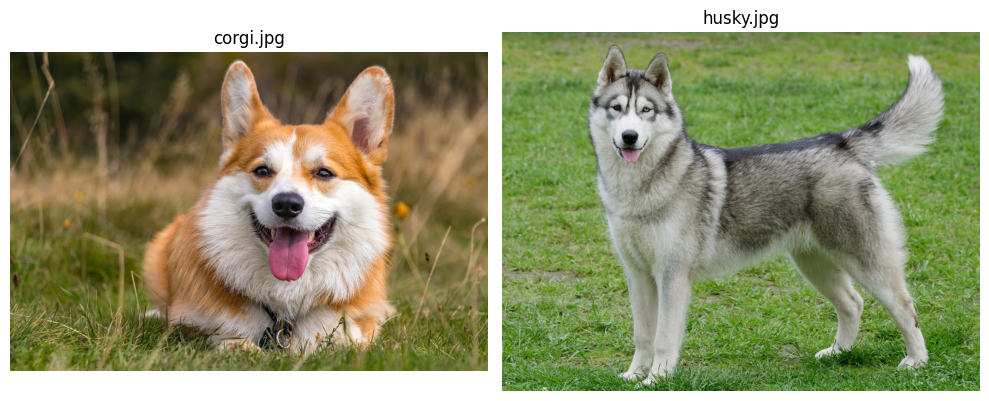

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

uris = results["uris"][0]
metadatas = results["metadatas"][0]

fig, axes = plt.subplots(1, len(uris), figsize=(5 * len(uris), 5))
if len(uris) == 1:
    axes = [axes]

for ax, uri, meta in zip(axes, uris, metadatas):
    ax.imshow(Image.open(uri))
    ax.set_title(meta.get("filename", uri))
    ax.axis("off")

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# Pull embeddings and build labels manually
results = collection.get(include=["embeddings", "metadatas"])

embeddings = np.array(results["embeddings"])
labels = [m["animal"] for m in results["metadatas"]]  # "dog" or "cat"

le = LabelEncoder()
y = le.fit_transform(labels)

clf = SVC(kernel="linear", probability=True)
clf.fit(embeddings, y)

# Query: classify a new image by its embedding
query_results = collection.query(query_texts=["a cat"], n_results=1, include=["embeddings"])
query_embedding = np.array(query_results["embeddings"][0])
pred = clf.predict(query_embedding)
print(le.inverse_transform(pred))  # "cat" or "dog"


['cat']


In [ ]:
# Query with an image
import numpy as np
from PIL import Image

# Load the query image
img = np.array(Image.open("classify_image_set_1/golden_retriever.jpg"))

results = collection.query(
    query_images=[img],
    n_results=3,
    include=["uris", "metadatas", "distances"]
)

print(results)


{'ids': [['labrador', 'corgi', 'husky']], 'embeddings': None, 'documents': None, 'uris': [['image_set_1/labrador.jpg', 'image_set_1/corgi.jpg', 'image_set_1/husky.jpg']], 'included': ['uris', 'metadatas', 'distances'], 'data': None, 'metadatas': [[{'filename': 'labrador.jpg', 'animal': 'dog'}, {'filename': 'corgi.jpg', 'animal': 'dog'}, {'animal': 'dog', 'filename': 'husky.jpg'}]], 'distances': [[0.2928760051727295, 0.2937411069869995, 0.40054571628570557]]}


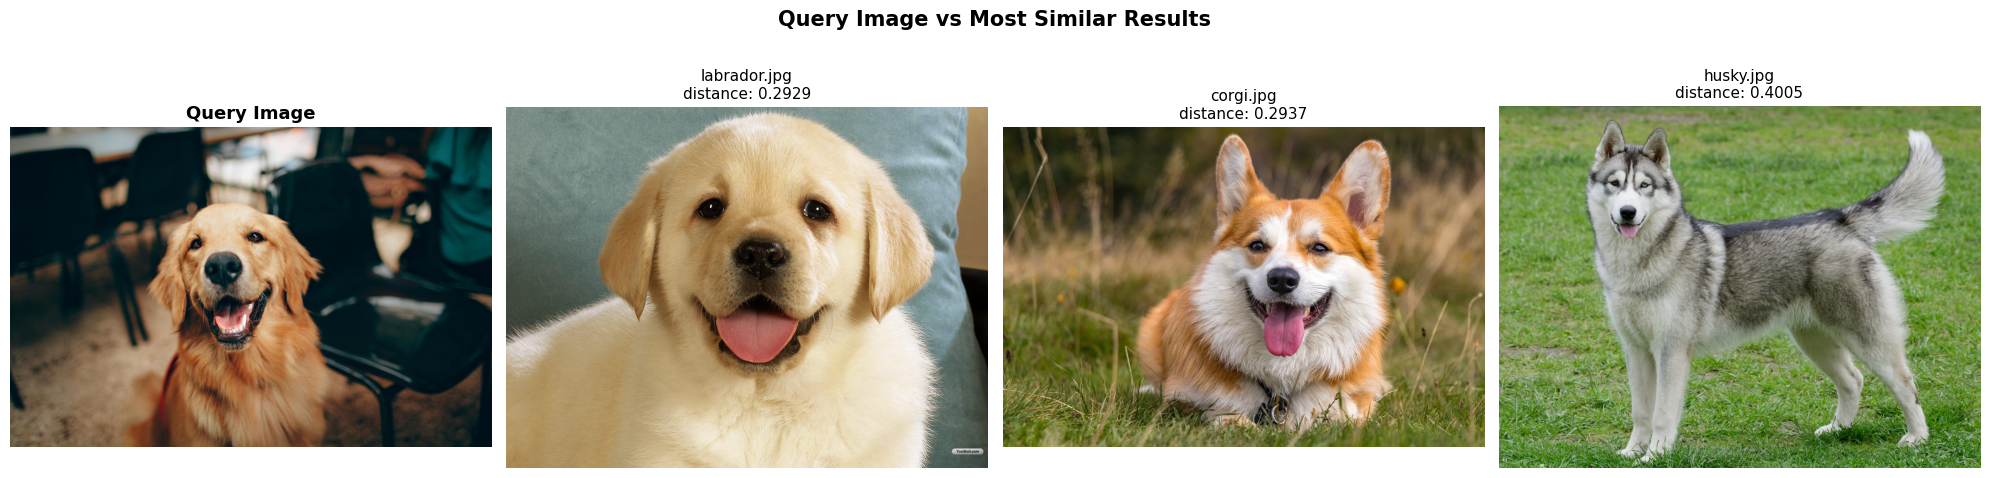

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

query_img = np.array(Image.open("classify_image_set_1/golden_retriever.jpg"))

results = collection.query(
    query_images=[query_img],
    n_results=3,
    include=["uris", "metadatas", "distances"]
)

uris = results["uris"][0]
distances = results["distances"][0]
metadatas = results["metadatas"][0]

fig, axes = plt.subplots(1, len(uris) + 1, figsize=(5 * (len(uris) + 1), 5))

# Show query image
axes[0].imshow(query_img)
axes[0].set_title("Query Image", fontsize=13, fontweight="bold")
axes[0].axis("off")

# Show results
for ax, uri, dist, meta in zip(axes[1:], uris, distances, metadatas):
    ax.imshow(Image.open(uri))
    ax.set_title(f"{meta.get('filename', uri)}\ndistance: {dist:.4f}", fontsize=11)
    ax.axis("off")

plt.suptitle("Query Image vs Most Similar Results", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
